In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("auto-mpg.csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
print(df.info())

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None

Columns:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [4]:
X = df[['displacement']]

y = df['mpg']

print(X.shape)
print(y.shape)

(398, 1)
(398,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(318, 1)
(80, 1)


In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Slope:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

Slope: [-0.06172521]
Intercept: 35.45349527608239


In [7]:
y_pred_linear = linear_model.predict(X_test)

print("Actual Values:")
print(y_test.head())

print("\nPredicted Values:")
print(y_pred_linear[:5])

Actual Values:
198    33.0
396    28.0
33     19.0
208    13.0
93     14.0
Name: mpg, dtype: float64

Predicted Values:
[29.83650162 28.04647068 21.13324772 15.82488009 15.82488009]


In [8]:
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")

print("MSE :", mse_linear)
print("R2 :", r2_linear)

Linear Regression
MSE : 18.102543998358946
R2 : 0.6633114869465596


In [9]:
degrees = [2, 3, 4]

results = []

for degree in degrees:

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)

    X_test_poly = poly.transform(X_test)

    # Scale polynomial features
    scaler = StandardScaler()

    X_train_poly = scaler.fit_transform(X_train_poly)

    X_test_poly = scaler.transform(X_test_poly)

    # Train model
    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    # Predict
    y_poly_pred = model.predict(X_test_poly)

    # Evaluate
    mse = mean_squared_error(y_test, y_poly_pred)

    r2 = r2_score(y_test, y_poly_pred)

    results.append([degree, mse, r2])

In [10]:
results_df = pd.DataFrame(
    results,
    columns=["Degree", "MSE", "R2 Score"]
)

print("\nComparison with Linear Regression\n")

print("Linear Regression")

print("MSE :", mse_linear)

print("R² :", r2_linear)

print("\nPolynomial Regression")

print(results_df)


Comparison with Linear Regression

Linear Regression
MSE : 18.102543998358946
R² : 0.6633114869465596

Polynomial Regression
   Degree        MSE  R2 Score
0       2  15.107354  0.719019
1       3  14.943632  0.722064
2       4  14.961487  0.721732


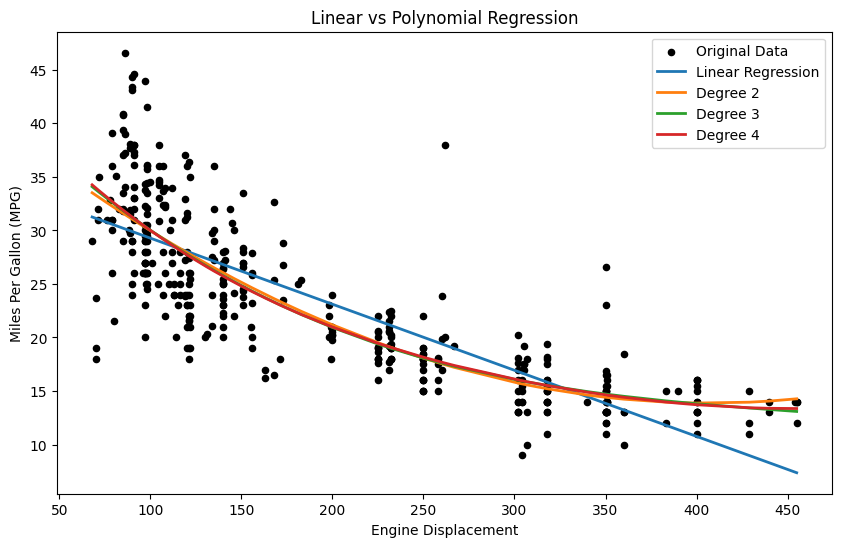

In [11]:
plt.figure(figsize=(10,6))

# Original data
plt.scatter(X, y, color="black", s=20, label="Original Data")

# Sort X values for smooth curves
X_plot = X.sort_values(by="displacement")

# Linear Regression Line
y_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot,
    y_linear,
    linewidth=2,
    label="Linear Regression"
)

# Polynomial Curves
for degree in degrees:

    poly = PolynomialFeatures(degree=degree)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_poly, y)

    X_plot_poly = poly.transform(X_plot)

    y_plot = model.predict(X_plot_poly)

    plt.plot(
        X_plot,
        y_plot,
        linewidth=2,
        label=f"Degree {degree}"
    )

plt.xlabel("Engine Displacement")

plt.ylabel("Miles Per Gallon (MPG)")

plt.title("Linear vs Polynomial Regression")

plt.legend()

plt.show()